In [1]:
import pandas as pd
import numpy as np

In [2]:
import statsmodels.api as sm 
from statsmodels.formula.api import ols
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [3]:
import statsmodels.formula.api as smf

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

In [5]:
fpath = 'C:\\Users\\gg00642\\OneDrive - University of Surrey\\Desktop\\Actigraphy Sara'

In [6]:
df = pd.read_excel(fpath + '\\5.0_database_variables.xlsx')

In [7]:
df = df.rename(columns={'location(ita=0,uk=1,usa=2)': 'location', 'week(1=free days)': 'weekday_type'})

In [8]:
# remove outliers
df = df[(np.abs(stats.zscore(df['sleep_duration(h)_UTC'])) < 3)]
df = df[(np.abs(stats.zscore(df['midpoint_h_UTC'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_start_decimal_UTC'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_end_decimal_UTC'])) < 3)]
df = df[(np.abs(stats.zscore(df['phase(sleepoffset-sunrise)'])) < 3)]

In [9]:
df = df.drop('sunrise_time(USA)', axis=1)
df = df.drop('sunrise (USA), hours', axis=1)
df = df.drop('sunset (USA), hours', axis=1)
df = df.drop('sunset_time(USA)', axis=1)
df = df.drop('photoperiod (h, USA)', axis=1)

In [10]:
# Define the start date
start_date = pd.to_datetime('2022-09-21')

In [11]:
# Function to calculate the week of the year from the start date
def calculate_week_of_year(date):
    year_diff = date.year - start_date.year
    start_of_year = pd.to_datetime(f'{date.year}-01-01')
    weeks_from_start = ((date - start_of_year).days // 7) + 1
    return year_diff * 52 + weeks_from_start

# Apply the function to calculate the week of the year
df['week_of_year'] = df['date'].apply(calculate_week_of_year)

In [12]:
# adjust 'week of the year' to start from 0
df['week_of_year'] = df['week_of_year'] - 37

In [13]:
# rename the location column as 0=ITA, 1=UK
df['location'] = df['location'].map({0: 'ITA', 1: 'UK'})

# rename the weekday column as 0=work days, 1=free days
df['weekday_type'] = df['weekday_type'].map({0: 'work days', 1: 'free days'})

In [14]:
# calculate the sleep duration for work days and free days
df['sleep_duration(h)_UTC'] = df['sleep_duration(h)_UTC'].astype(float)
df['sleep_duration_work_days_UTC'] = df['sleep_duration(h)_UTC'] * (df['weekday_type'] == 'work days')
df['sleep_duration_free_days_UTC'] = df['sleep_duration(h)_UTC'] * (df['weekday_type'] == 'free days')

In [15]:
# sleep loss
# if sleep duration work > sleep duration free -> (sleep duration on work days - sleep duration on free days) - day of the week
# if sleep duration work < sleep duration free -> (sleep duration on work days - sleep duration on free days) - free days
df['sleep_loss_UTC'] = (df['sleep_duration_work_days_UTC'] - df['sleep_duration_free_days_UTC']) * (df['sleep_duration_work_days_UTC'] > df['sleep_duration_free_days_UTC']) + \
    (df['sleep_duration_work_days_UTC'] - df['sleep_duration_free_days_UTC']) * (df['sleep_duration_work_days_UTC'] < df['sleep_duration_free_days_UTC'])

In [16]:
# filtered the midpoints by type of day of the week
# new dataframe with only the midpoints of the work days/free days
df_workdays = df[df['weekday_type'] == 'work days']
df_freedays = df[df['weekday_type'] == 'free days']

In [17]:
data_jetlag_UTC = df #df for weekly jetlag analysis

In [18]:
# calculate the mean midpoint for each location, week and weekday
weekly_means_jetlag_UTC = data_jetlag_UTC.groupby(['location', 'week_of_year', 'weekday_type'])['midpoint_h_UTC'].mean().unstack()

In [19]:
weekly_means_jetlag_UTC['jet lag_UTC'] = weekly_means_jetlag_UTC['free days'] - weekly_means_jetlag_UTC['work days']

In [20]:
# add a column with the location
weekly_means_jetlag_UTC['location'] = weekly_means_jetlag_UTC.index.get_level_values(0)

In [21]:
df = df.rename(columns={'sleep_duration(h)_UTC': 'sleep_duration_UTC'})
df = df.rename(columns={'phase(sleepoffset-sunrise)': 'phase'})

In [22]:
# Adding a 'season' column to the dataset based on the 'date' column
# Defining seasons based on months: 
# Winter (Dec-Feb), Spring (Mar-May), Summer (Jun-Aug), Autumn (Sep-Nov)
def assign_season(date):
    month = pd.to_datetime(date).month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

In [23]:
# Applying the function to create a season column
df_workdays['season'] = df_workdays['date'].apply(assign_season)
df_freedays['season'] = df_freedays['date'].apply(assign_season)
df['season'] = df['date'].apply(assign_season)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_14120\2974399819.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays['season'] = df_workdays['date'].apply(assign_season)
C:\Users\gg00642\AppData\Local\Temp\ipykernel_14120\2974399819.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays['season'] = df_freedays['date'].apply(assign_season)


In [24]:
# if column 'location' = 1 take the value from 'photoperiod (h, UK)' 
# if column 'location' = 0 then photoperiod (h, ITA)'
df['photoperiod'] = np.where(df['location'] == 'UK', df['photoperiod (h, UK)'], df['photoperiod (h, ITA)'])
df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)'] # add a column with the photoperiod for the UK
df_workdays.loc[df_workdays['location'] == 'ITA', 'photoperiod'] = df_workdays['photoperiod (h, ITA)']

C:\Users\gg00642\AppData\Local\Temp\ipykernel_14120\1293994927.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)'] # add a column with the photoperiod for the UK


In [25]:
df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']
df_freedays.loc[df_freedays['location'] == 'ITA', 'photoperiod'] = df_freedays['photoperiod (h, ITA)']

C:\Users\gg00642\AppData\Local\Temp\ipykernel_14120\1486412571.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']


# EDA

In [26]:
all_descriptive = df.describe()
all_descriptive = all_descriptive.transpose()

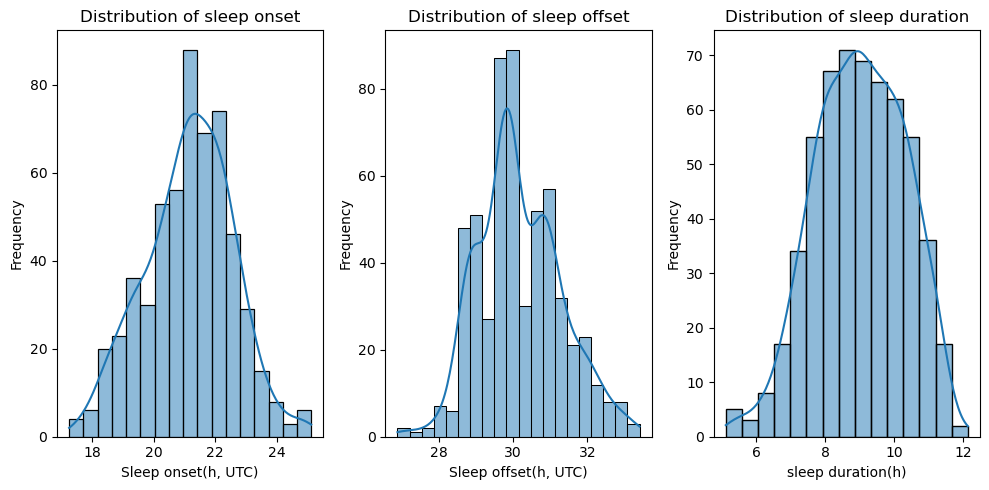

In [27]:
# Distribution 
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['sleep_start_decimal_UTC'].dropna(), kde=True)
plt.title("Distribution of sleep onset")
plt.xlabel("Sleep onset(h, UTC)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
sns.histplot(df['sleep_end_decimal_UTC'].dropna(), kde=True)
plt.title("Distribution of sleep offset")
plt.xlabel("Sleep offset(h, UTC)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
sns.histplot(df['sleep_duration_UTC'].dropna(), kde=True)
plt.title("Distribution of sleep duration")
plt.xlabel("sleep duration(h)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

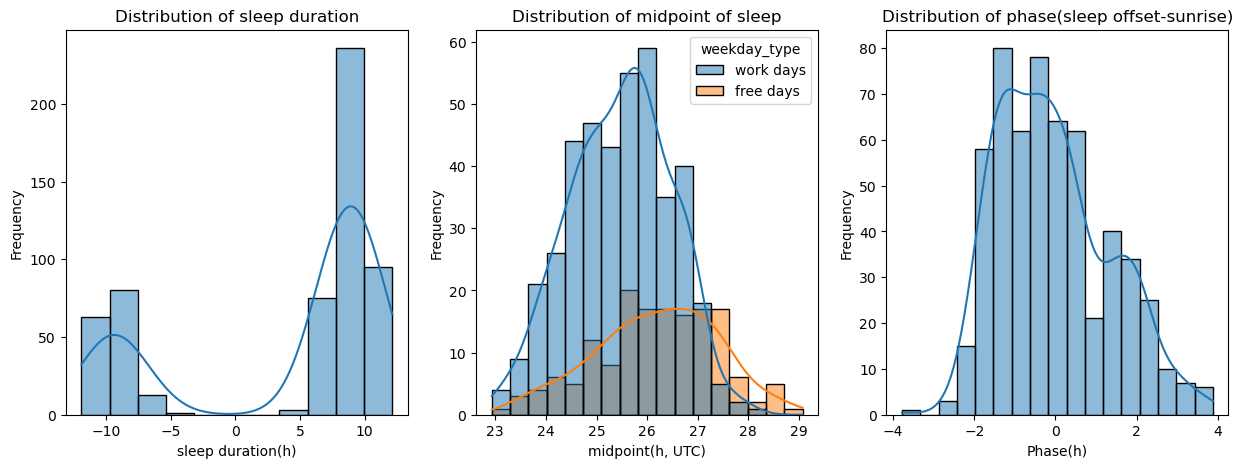

<Figure size 640x480 with 0 Axes>

In [ ]:
# Distribution 
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['sleep_loss_UTC'].dropna(), kde=True)
plt.title("Distribution of sleep loss")
plt.xlabel("sleep loss(h)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
sns.histplot(data=df, x='midpoint_h_UTC', hue='weekday_type', kde=True)
plt.title("Distribution of midpoint of sleep")
plt.xlabel("midpoint(h, UTC)")
plt.ylabel("Frequency")

plt.subplot(1,3,3)
sns.histplot(df['phase'].dropna(), kde=True)
plt.title("Distribution of phase(sleep offset-sunrise)")
plt.xlabel("Phase(h)")
plt.ylabel("Frequency")
plt.show()

plt.tight_layout()
plt.show()

In [29]:
# test normality of the data using Shapiro-Wilk test 
# H0: data is normally distributed
shapiro_test_sleep_duration = stats.shapiro(df['sleep_duration_UTC'])
shapiro_test_sleeploss = stats.shapiro(df['sleep_loss_UTC'])
shapiro_test_midpoint = stats.shapiro(df['midpoint_h_UTC'])
shapiro_test_sleep_start = stats.shapiro(df['sleep_start_decimal_UTC'])
shapiro_test_sleep_end = stats.shapiro(df['sleep_end_decimal_UTC'])
shapiro_test_phase = stats.shapiro(df['phase'])

In [30]:
shapiro_results_descriptive = pd.DataFrame({
    'Variable': ['sleep_duration(h)', 'sleep_loss_UTC', 'midpoint_h_UTC', 'sleep_start_decimal_UTC', 'sleep_end_decimal_UTC', 'phase(sleepoffset-sunrise)'],
    'Shapiro-Wilk test': [shapiro_test_sleep_duration, shapiro_test_sleeploss, shapiro_test_midpoint, shapiro_test_sleep_start, shapiro_test_sleep_end, shapiro_test_phase]
})

In [31]:
shapiro_results_descriptive

,Variable,Shapiro-Wilk test
0,sleep_duration(h),"(0.9902246610911858, 0.0008226033160291848)"
1,sleep_loss_UTC,"(0.6997461052790972, 1.5493129771511592e-30)"
2,midpoint_h_UTC,"(0.9966098081502522, 0.27825571498290286)"
3,sleep_start_decimal_UTC,"(0.9938769987889519, 0.021848420182686012)"
4,sleep_end_decimal_UTC,"(0.9836545244937268, 5.6566874049762885e-06)"
5,phase(sleepoffset-sunrise),"(0.9661064505005437, 3.7966420613702094e-10)"


In [32]:
#shapiro of midpoint free days and work days
shapiro_test_midpoint_free = stats.shapiro(df[df['weekday_type'] == 'free days']['midpoint_h_UTC'])
shapiro_test_midpoint_work = stats.shapiro(df[df['weekday_type'] == 'work days']['midpoint_h_UTC'])

In [33]:
shapiro_results_free_work = pd.DataFrame({
    'Weekday type': ['free days', 'work days'],
    'Shapiro-Wilk test': [shapiro_test_midpoint_free, shapiro_test_midpoint_work]
})

In [34]:
shapiro_results_free_work

,Weekday type,Shapiro-Wilk test
0,free days,"(0.9894810197523596, 0.29179366919766936)"
1,work days,"(0.9929247333891301, 0.050973709866609325)"


In [35]:
df_grouped_location = df.groupby('location').describe()
df_grouped_location = df_grouped_location.transpose()

In [36]:
df_grouped_weekday = df.groupby('weekday_type').describe()
df_grouped_weekday = df_grouped_weekday.transpose()

In [37]:
df_grouped_location_weekday = df.groupby(['location', 'weekday_type']).describe()
df_grouped_location_weekday = df_grouped_location_weekday.transpose()

In [38]:
# compare the midpoint, duration and phase between the two locations
ttest_midpoint_workdays_loc = stats.ttest_ind(df_workdays[df_workdays['location'] == 'ITA']['midpoint_h_UTC'], df_workdays[df_workdays['location'] == 'UK']['midpoint_h_UTC'])
ttest_midpoint_freedays_loc = stats.ttest_ind(df_freedays[df_freedays['location'] == 'ITA']['midpoint_h_UTC'], df_freedays[df_freedays['location'] == 'UK']['midpoint_h_UTC'])
utest_duration_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_duration_UTC'], df[df['location'] == 'UK']['sleep_duration_UTC'])
utest_sleeploss_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_loss_UTC'], df[df['location'] == 'UK']['sleep_loss_UTC'])   
utest_phase_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['phase'], df[df['location'] == 'UK']['phase'])
utest_start_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_start_decimal_UTC'], df[df['location'] == 'UK']['sleep_start_decimal_UTC'])
utest_end_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_end_decimal_UTC'], df[df['location'] == 'UK']['sleep_end_decimal_UTC'])

# compare the midpoint, duration and phase between work days and free days
ttest_midpoint_week = stats.ttest_ind(df[df['weekday_type'] == 'work days']['midpoint_h_UTC'], df[df['weekday_type'] == 'free days']['midpoint_h_UTC'])
utest_duration_week = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['sleep_duration_UTC'], df[df['weekday_type'] == 'free days']['sleep_duration_UTC'])
utest_sleeploss_week = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['sleep_loss_UTC'], df[df['weekday_type'] == 'free days']['sleep_loss_UTC'])
utest_phase_week = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['phase'], df[df['weekday_type'] == 'free days']['phase'])
utest_start_week = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['sleep_start_decimal_UTC'], df[df['weekday_type'] == 'free days']['sleep_start_decimal_UTC'])
utest_end_week = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['sleep_end_decimal_UTC'], df[df['weekday_type'] == 'free days']['sleep_end_decimal_UTC'])

In [39]:
print('T test results for location')
print('Midpoint_work:', ttest_midpoint_workdays_loc)
print('Midpoint_free:', ttest_midpoint_freedays_loc)
print('U test results for location')
print('Sleep_onset:', utest_start_loc)
print('Sleep_offset:', utest_end_loc)
print('Sleep_duration:', utest_duration_loc)
print('Sleep_loss:', utest_sleeploss_loc)
print('Phase:', utest_phase_loc)

T test results for location
Midpoint_work: TtestResult(statistic=-7.002582947406899, pvalue=1.044280679209457e-11, df=407.0)
Midpoint_free: TtestResult(statistic=-3.8479181254840364, pvalue=0.00017370196992224848, df=155.0)
U test results for location
Sleep_onset: MannwhitneyuResult(statistic=29056.0, pvalue=6.015842573800659e-07)
Sleep_offset: MannwhitneyuResult(statistic=24049.5, pvalue=2.6869544574564792e-14)
Sleep_duration: MannwhitneyuResult(statistic=37478.0, pvalue=0.5617529447997844)
Sleep_loss: MannwhitneyuResult(statistic=36996.5, pvalue=0.4051877555986151)
Phase: MannwhitneyuResult(statistic=23915.0, pvalue=1.5550327829417426e-14)


In [40]:
print('T test results for free/work days:') 
print('Midpoint:', ttest_midpoint_week)
print('U test results for free/work days:')
print('Sleep_onset:', utest_start_week)
print('Sleep_offset:', utest_end_week)
print('Sleep_duration:', utest_duration_week)
print('Sleep_loss:', utest_sleeploss_week)
print('Phase:', utest_phase_week)

T test results for free/work days:
Midpoint: TtestResult(statistic=-7.1766001931353305, pvalue=2.2617971926824492e-12, df=564.0)
U test results for free/work days:
Sleep_onset: MannwhitneyuResult(statistic=25876.5, pvalue=0.00034838522139971713)
Sleep_offset: MannwhitneyuResult(statistic=18376.5, pvalue=3.2166591077253687e-15)
Sleep_duration: MannwhitneyuResult(statistic=26296.0, pvalue=0.0008513645734632195)
Sleep_loss: MannwhitneyuResult(statistic=64213.0, pvalue=7.261341471533861e-76)
Phase: MannwhitneyuResult(statistic=20575.5, pvalue=3.6001724806582534e-11)


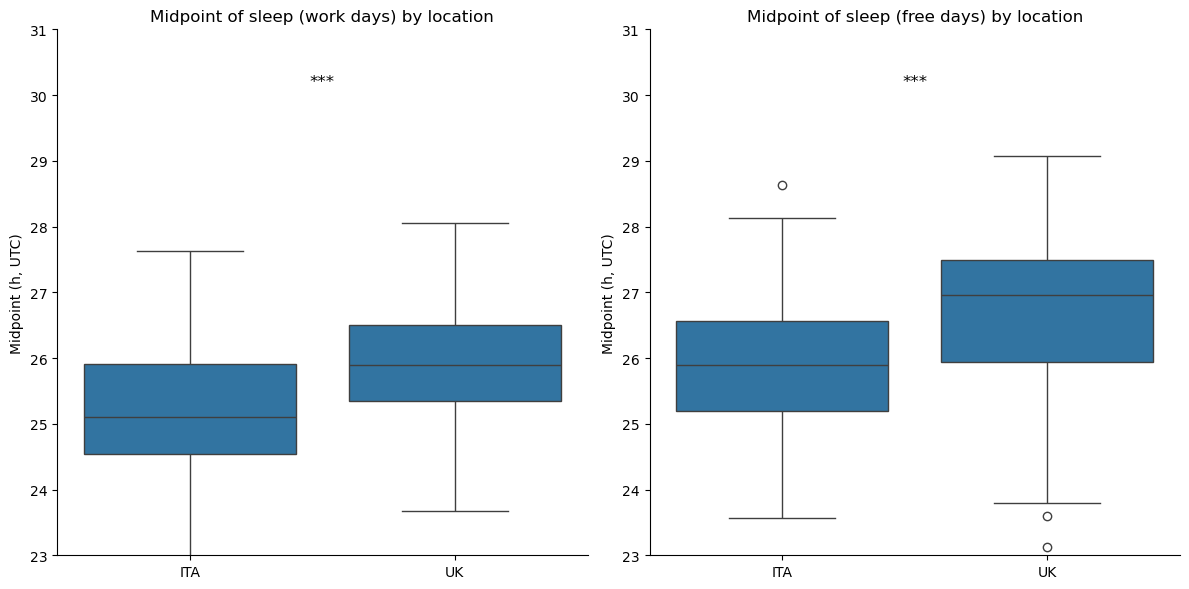

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(x='location', y='midpoint_h_UTC', data=df_workdays, ax=ax[0])
ax[0].set_title('Midpoint of sleep (work days) by location')
ax[0].set_ylabel('Midpoint (h, UTC)')
ax[0].set_xlabel('')
ax[0].yaxis.set_major_locator(MultipleLocator(1))
ax[0].set_ylim(23, 31)
#add a significance line of ** for the p-value < 0.01
if ttest_midpoint_workdays_loc.pvalue < 0.001:
    ax[0].annotate('***', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', va='center', fontsize=12) 

sns.boxplot(x='location', y='midpoint_h_UTC', data=df_freedays, ax=ax[1])
ax[1].set_title('Midpoint of sleep (free days) by location')
ax[1].set_ylabel('Midpoint (h, UTC)')
ax[1].set_xlabel('')
ax[1].yaxis.set_major_locator(MultipleLocator(1))
ax[1].set_ylim(ax[0].get_ylim())

#add a significance line of  for the p-value < 0.05
if ttest_midpoint_freedays_loc.pvalue < 0.001:
    ax[1].annotate('***', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', va='center', fontsize=12) 
    
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black') # set the color of the x-axis to black
plt.gca().spines['left'].set_color('black')
plt.tight_layout()
plt.show()

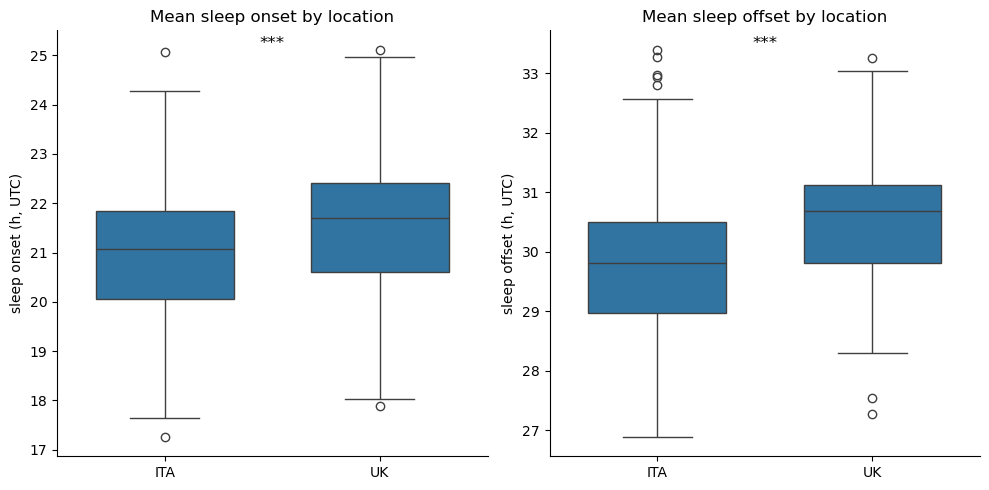

In [42]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='sleep_start_decimal_UTC', data=df, gap=0.2)
plt.title("Mean sleep onset by location")
plt.xlabel("")
plt.ylabel("sleep onset (h, UTC)")
#add a significance line to the subplot
if utest_start_loc.pvalue < 0.001:
    plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

plt.subplot(1, 2, 2)
sns.boxplot(x='location', y='sleep_end_decimal_UTC', data=df, gap=0.2)
plt.title("Mean sleep offset by location")
plt.xlabel("")
plt.ylabel("sleep offset (h, UTC)")
#add a significance line 
if utest_end_loc.pvalue < 0.001:
    plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

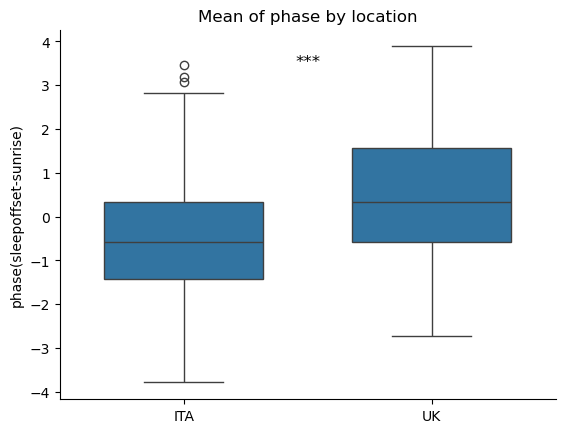

In [43]:
plt.figure()
sns.boxplot(x='location', y='phase', data=df, gap=0.2)
plt.title('Mean of phase by location')
plt.xlabel('')
plt.ylabel('phase(sleepoffset-sunrise)')
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black') # set the color of the x-axis to black
plt.gca().spines['left'].set_color('black')

#add a significance line 
if utest_phase_loc.pvalue < 0.001:
    plt.annotate('***', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', fontsize=12)
plt.show()

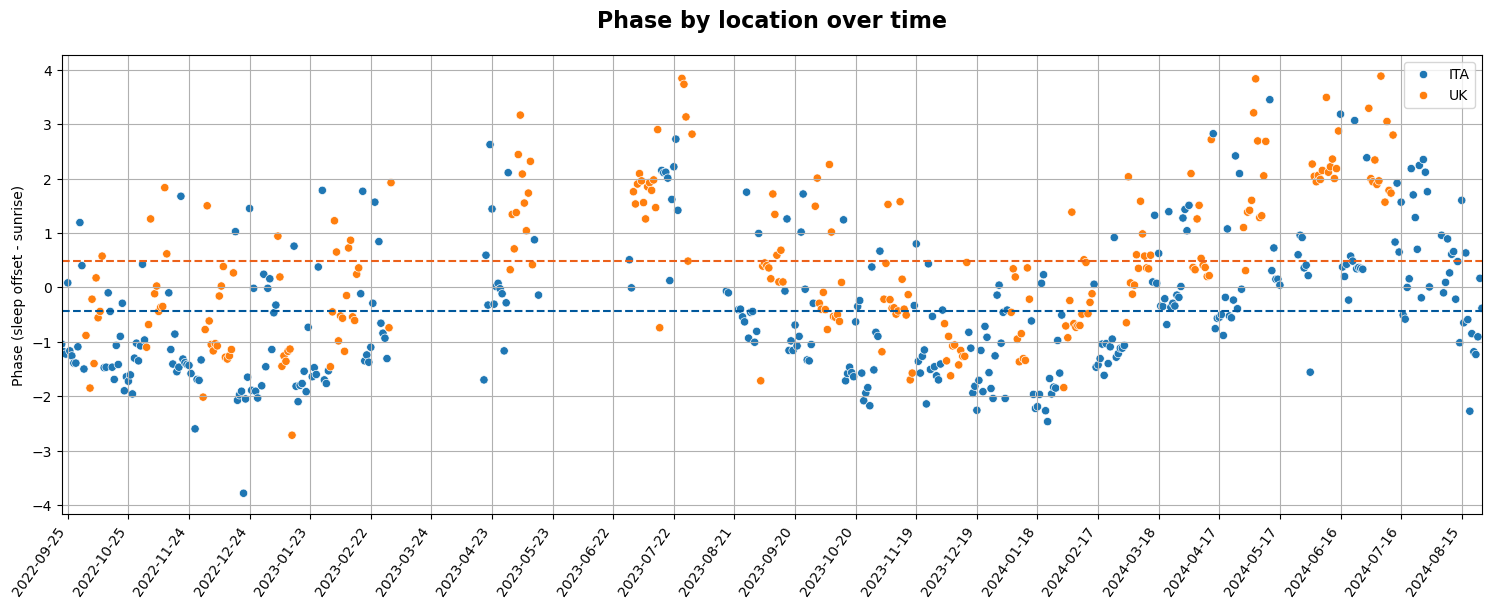

In [44]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='phase', hue='location', data=df)
plt.title('Phase by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Phase (sleep offset - sunrise)')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())

# get the current axes then set the x-axis major locator
# plot.gca()=ax if set ax = plt.gca()
plt.gca().xaxis.set_major_locator(MultipleLocator(30)) 

#add the mean of the phase for the two locations
plt.axhline(df[df['location'] == 'ITA']['phase'].mean(), color='#00589c', linestyle='--', label='ITA mean')
plt.axhline(df[df['location'] == 'UK']['phase'].mean(), color='#ec611a', linestyle='--', label='UK mean')

plt.show()

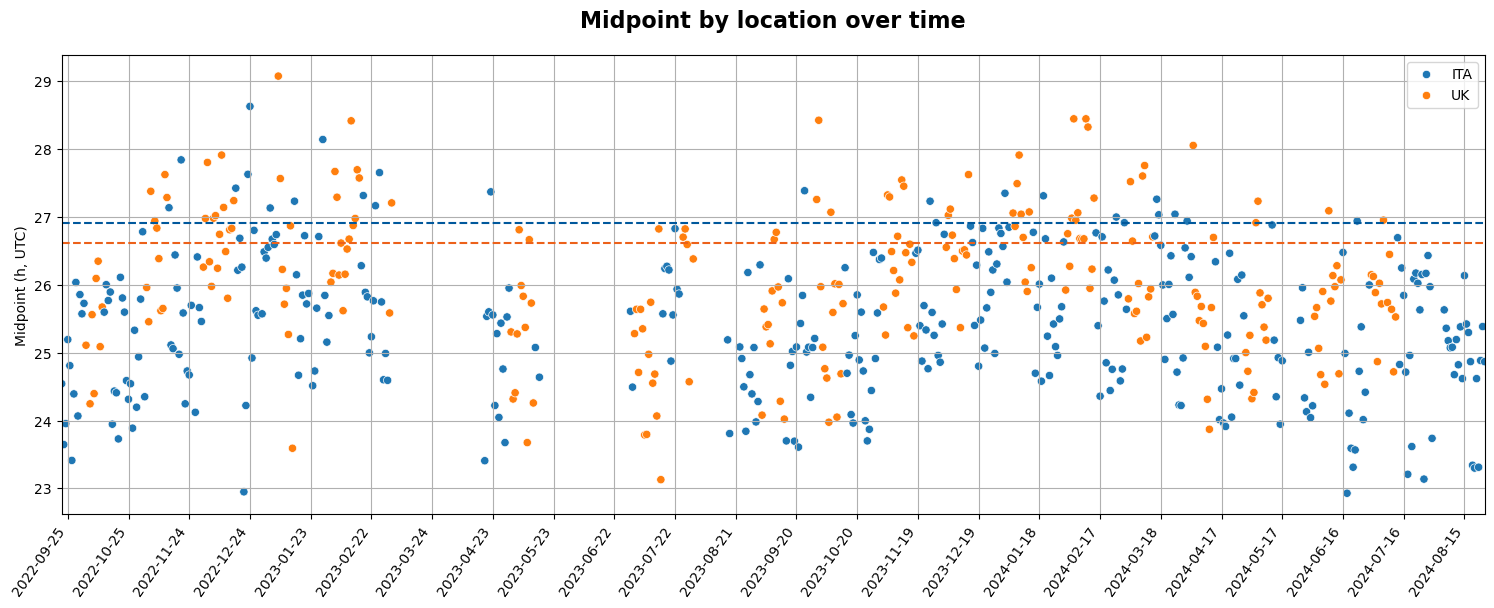

In [45]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='midpoint_h_UTC', hue='location', data=df)
plt.title('Midpoint by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Midpoint (h, UTC)')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())

# get the current axes then set the x-axis major locator
# plot.gca()=ax if set ax = plt.gca()
plt.gca().xaxis.set_major_locator(MultipleLocator(30)) 

#add the mean of the phase for the two locations
plt.axhline(df[df['location'] == 'ITA']['midpoint_h'].mean(), color='#00589c', linestyle='--', label='ITA mean')
plt.axhline(df[df['location'] == 'UK']['midpoint_h'].mean(), color='#ec611a', linestyle='--', label='UK mean')

plt.show()

_Jetlag_

In [ ]:
# Plot the weekly jet lag between UK and ITA
plt.figure(figsize=(12, 6))
sns.lineplot(x='week_of_year', y='jet lag_UTC', hue='location', data=weekly_means_jetlag_UTC, marker='o', palette=['darkblue', 'darkorange'])
plt.title('Weekly jet lag over time between UK and ITA (from 21-09-2022)')
plt.xlabel('Weeks counted')
plt.ylabel('Jet Lag (h)')
plt.legend(title='Location', labels=['ITA', 'UK'], loc='upper right', handles=[plt.Line2D([0], [0], color='darkblue', lw=2), plt.Line2D([0], [0], color='darkorange', lw=2)])
plt.grid(True)
plt.xlim(0, 104)
plt.gca().xaxis.set_major_locator(MultipleLocator(4)) 
plt.xticks()
plt.show()

In [ ]:
# Remove NaN values before performing the Shapiro-Wilk test
jetlag_no_nan = weekly_means_jetlag_UTC['jet lag_UTC'].dropna()

In [ ]:
# Test normality of the jet lag data using Shapiro-Wilk test 
# H0: data is normally distributed
shapiro_test_jetlag = stats.shapiro(jetlag_no_nan)

In [ ]:
shapiro_test_jetlag

In [ ]:
# Perform a t-test to compare the jet lag between the two locations
ttest_jetlag = stats.ttest_ind(weekly_means_jetlag_UTC[weekly_means_jetlag_UTC['location'] == 'ITA']['jet lag_UTC'].dropna(), weekly_means_jetlag_UTC[weekly_means_jetlag_UTC['location'] == 'UK']['jet lag_UTC'].dropna())

In [ ]:
print('Results for jet lag:')
print(ttest_jetlag)

_Seasonal effect_

In [ ]:
df = df.dropna(subset=['sleep_duration_UTC'])
df = df.dropna(subset=['phase'])

In [ ]:
anova_midpoint_work_season1 = ols('midpoint_h_UTC ~ C(season)', data=df_workdays).fit()

In [ ]:
anova_midpoint_free_season1 = ols('midpoint_h_UTC ~ C(season)', data=df_freedays).fit()

In [ ]:
anova_midpoint_work_result_season1 = sm.stats.anova_lm(anova_midpoint_work_season1, typ=3) #fit the ANOVA model and get the results

In [ ]:
anova_midpoint_free_result_season1 = sm.stats.anova_lm(anova_midpoint_free_season1, typ=3)

In [ ]:
print("\nANOVA_midpoint work Results:")
print(anova_midpoint_work_result_season1)
print("\nANOVA_midpoint free Results:")
print(anova_midpoint_free_result_season1)

In [ ]:
# Kruskal-Wallis test 
kw_sleep_duration_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_duration_UTC'], df[df['season'] == 'Spring']['sleep_duration_UTC'], df[df['season'] == 'Summer']['sleep_duration_UTC'], df[df['season'] == 'Autumn']['sleep_duration_UTC'])
kw_phase_season = stats.kruskal(df[df['season'] == 'Winter']['phase'], df[df['season'] == 'Spring']['phase'], df[df['season'] == 'Summer']['phase'], df[df['season'] == 'Autumn']['phase'])
kw_start_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_start_decimal_UTC'], df[df['season'] == 'Spring']['sleep_start_decimal_UTC'], df[df['season'] == 'Summer']['sleep_start_decimal_UTC'], df[df['season'] == 'Autumn']['sleep_start_decimal_UTC'])
kw_end_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_end_decimal_UTC'], df[df['season'] == 'Spring']['sleep_end_decimal_UTC'], df[df['season'] == 'Summer']['sleep_end_decimal_UTC'], df[df['season'] == 'Autumn']['sleep_end_decimal_UTC'])

In [ ]:
print('Results for Kruskal-Wallis test for the sleep duration by season')
print(kw_sleep_duration_season)
print('Results for Kruskal-Wallis test for the phase by season')
print(kw_phase_season)
print('Results for Kruskal-Wallis test for the sleep onset by season')
print(kw_start_season)
print('Results for Kruskal-Wallis test for the sleep offset by season')
print(kw_end_season)

In [ ]:
# perform a Tukey HSD test to compare the means
tukey_results_season1 = pairwise_tukeyhsd(df_workdays['midpoint_h_UTC'], df_workdays['season'])
print(tukey_results_season1)

In [ ]:
# Perform a Tukey HSD test to compare the means
tukey_results_season4 = pairwise_tukeyhsd(df['phase'], df['season'])
print(tukey_results_season4)

In [ ]:
# Sleep Midpoint (work) by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='midpoint_h_UTC', data=df_workdays)
plt.title('Sleep midpoint (workdays) by season')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Midpoint of sleep (h, UTC)')
plt.xlabel('')
sns.despine()
plt.grid(False)
#bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

In [ ]:
# Sleep Midpoint (free) by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='midpoint_h_UTC', data=df_freedays)
plt.title('Sleep midpoint (freedays) by season')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Midpoint of sleep (h, UTC)')
plt.xlabel('')
sns.despine()
plt.grid(False)
# bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

In [ ]:
# Sleep Duration by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='sleep_duration_UTC', data=df)
plt.title('Sleep Duration by season')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Sleep Duration (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
# bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

In [ ]:
# Sleep Phase by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='phase', data=df)
plt.title('Phase by season')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Phase (sleep offset - sunrise)')
plt.xlabel('')
sns.despine()
plt.grid(False)
# bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='season', y='sleep_start_decimal_UTC', data=df)
plt.title('Sleep onset by season')
plt.ylabel('Sleep onset (h, UTC)')
plt.xlabel('')

plt.subplot(1, 2, 2)
sns.boxplot(x='season', y='sleep_end_decimal_UTC', data=df)
plt.title('Sleep offset by season')
plt.ylabel('Sleep offset (h, UTC)')
plt.xlabel('')

# bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.tight_layout()

plt.show()

_Photoperiod and sleep-wake pattern_

In [ ]:
correlation_test1 = stats.pearsonr(df_workdays['midpoint_h_UTC'], df_workdays['photoperiod'])
correlation_test2 = stats.pearsonr(df_freedays['midpoint_h_UTC'], df_freedays['photoperiod'])
correlation_test3 = stats.spearmanr(df['sleep_start_decimal_UTC'], df['photoperiod'])
correlation_test4 = stats.spearmanr(df['sleep_end_decimal_UTC'], df['photoperiod'])

In [ ]:
# Extract the coefficients and p-values from the correlation test results
pearson_coeff = [correlation_test1.statistic, correlation_test2.statistic, correlation_test3.statistic, correlation_test4.statistic]
p_values = [correlation_test1.pvalue, correlation_test2.pvalue, correlation_test3.pvalue, correlation_test4.pvalue]

# Create a DataFrame with the results
correlation_results = pd.DataFrame({
    'Variables': ['midpoint (work) UTC vs photoperiod', 'midpoint (free) UTC vs photoperiod', 'sleep onset UTC vs photoperiod', 'sleep offset UTC vs photoperiod'],
    'Coefficient': pearson_coeff,
    'P-value': p_values
})

correlation_results

_Phase by location, time and photoperiod_

In [ ]:
data_phase = df.dropna(subset=['phase', 'location', 'date', 'photoperiod'])

In [ ]:
data_phase['location'] = data_phase['location'].map({'ITA': 0, 'UK': 1}) # convert the location to numerical values

In [ ]:
# Converting date to numerical values (days since the start of the observation period)
data_phase['date_numeric'] = (pd.to_datetime(data_phase['date']) - pd.to_datetime(data_phase['date']).min()).dt.days

In [ ]:
glm_model_phase_numeric1 = smf.glm(
    formula="phase ~ location + date_numeric ",
    data=data_phase,
    family=sm.families.Gaussian()
)

In [ ]:
# Fit of the model
glm_results_phase_numeric1 = glm_model_phase_numeric1.fit()

In [ ]:
# Output the summary of the model
glm_results_phase_numeric_summary1 = glm_results_phase_numeric1.summary()
glm_results_phase_numeric_summary1

In [ ]:
glm_model_phase_numeric2 = smf.glm(
    formula="phase ~ location + date_numeric + photoperiod",
    data=data_phase,
    family=sm.families.Gaussian()
)

In [ ]:
# Fit of the model
glm_results_phase_numeric2 = glm_model_phase_numeric2.fit()

In [ ]:
# Output the summary of the model
glm_results_phase_numeric_summary2 = glm_results_phase_numeric2.summary()
glm_results_phase_numeric_summary2

_Midpoint by location and week day_

In [ ]:
model_1 = ols('midpoint_h_UTC ~ C(location) * C(weekday_type)', data=df).fit() # C() is used to indicate categorical variables

In [ ]:
anova_results = sm.stats.anova_lm(model_1, typ=3)

In [ ]:
print("ANOVA Results:")
print(anova_results)

In [ ]:
# regression coefficients of the model (ita work days as the reference)
weights = model_1.params / model_1.params.abs().sum()
weights

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='midpoint_h_UTC', hue='weekday_type', data=df, gap=0.2)
plt.title('Mean of sleep midpoint by location and free/work days')
plt.xlabel('')
plt.ylim(23, 33)
plt.ylabel('Midpoint (h, UTC)')
plt.legend()
plt.show()

In [ ]:
model_work = smf.ols('midpoint_h_UTC ~ C(location) * photoperiod', data=df_workdays).fit()

In [ ]:
model_work.summary()

In [ ]:
model_free = smf.ols('midpoint_h_UTC ~ C(location) * photoperiod', data=df_freedays).fit()

In [ ]:
model_free.summary()

_Phase by location and week day_

In [ ]:
data_phase2 = df.dropna(subset=['phase', 'location', 'weekday_type'])

In [ ]:
glm_model_phase2 = smf.glm(
    formula="phase ~ location + weekday_type",
    data=data_phase2,
    family=sm.families.Gaussian()
)

In [ ]:
# Fit of the model
glm_results_phase2 = glm_model_phase2.fit()

In [ ]:
# Output the summary of the model (ita and free days as baseline)
glm_results_phase2_summary = glm_results_phase2.summary()
glm_results_phase2_summary

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='phase', hue='weekday_type', data=data_phase2, gap=0.2)
plt.title('Phase by location and free/work days')
plt.xlabel('Location')
plt.ylim(-7,7)
plt.ylabel('Phase, h [sleep offset - sunrise]')
plt.legend()

plt.show()

_Weekly IV, IS and RA_

In [ ]:
# Load the datasets
weekly_values = pd.read_csv(fpath + '\\weekly_IV_IS_RA_values_with_dates.csv')
weekly_jetlag = weekly_means_jetlag_UTC

In [ ]:
# Split Date_Range into Start_Date and End_Date in weekly_values
weekly_values[['Start_Date', 'End_Date']] = weekly_values['Date_Range'].str.split(' to ', expand=True)

In [ ]:
# Convert Start_Date and End_Date to datetime format
weekly_values['Start_Date'] = pd.to_datetime(weekly_values['Start_Date'])
weekly_values['End_Date'] = pd.to_datetime(weekly_values['End_Date'])

In [ ]:
# Merge by matching the week number extracted from Start_Date with week_of_year in weekly_jetlag
merged_data = pd.merge(
    weekly_values,
    weekly_jetlag,
    left_on=weekly_values['Start_Date'].dt.isocalendar().week,
    right_on='week_of_year',
    how='inner'
)

merged_data.head()

In [ ]:
# Summary statistics
summary_stats = merged_data.groupby("location")[['IV', 'IS', 'RA']].describe()
summary_stats

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
sns.histplot(merged_data['IV'].dropna(), kde=True)
plt.title("Distribution of IV")
plt.xlabel("IV")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
sns.histplot(merged_data['IS'].dropna(), kde=True)
plt.title('Distribution of IS')
plt.xlabel('IS')
plt.ylabel('Frequency')
 
plt.subplot(1, 3, 3)
sns.histplot(merged_data['RA'].dropna(), kde=True)
plt.title("Distribution of RA")
plt.xlabel("RA")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
iv_ttest = stats.ttest_ind(merged_data[merged_data['location'] == 'ITA']['IV'], merged_data[merged_data['location'] == 'UK']['IV'], nan_policy='omit')
is_ttest = stats.mannwhitneyu(merged_data[merged_data['location'] == 'ITA']['IS'], merged_data[merged_data['location'] == 'UK']['IS'], nan_policy='omit')
ra_ttest = stats.ttest_ind(merged_data[merged_data['location'] == 'ITA']['RA'], merged_data[merged_data['location'] == 'UK']['RA'], nan_policy='omit')

In [ ]:
print("\nT-test results for IV by Location:", iv_ttest)
print("U-test results for IS by Location:", is_ttest)
print("T-test results for RA by Location:", ra_ttest)

In [ ]:
plt.figure(figsize=(12, 5))

# IV by Location
plt.subplot(1, 3, 1)
sns.boxplot(x="location", y="IV", data=merged_data)
plt.title("IV by Location")
plt.xlabel("Location")
plt.ylabel("IV")

# IS by Location
plt.subplot(1, 3, 2)
sns.boxplot(x="location", y="IS", data=merged_data)
plt.title("IS by Location")
plt.xlabel("Location")
plt.ylabel("IS")

plt.subplot(1, 3, 3)
sns.boxplot(x="location", y="RA", data=merged_data)
plt.title("RA by Location")
plt.xlabel("Location")
plt.ylabel("RA")

sns.despine()
plt.tight_layout()
plt.show()